In [1]:
# Run in terminal: pip install pandas numpy matplotlib seaborn scikit-learn xgboost scipy openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from scipy import stats

Step 2: Load and Clean All Data
Load funds, macro, and previous KSE-30 data; merge on date.

In [3]:
# File paths (adjust as needed)
funds_path = 'data/funds_data.xlsx'
macro_path = 'data/macro_data.xlsx'
kse30_path = 'data/kse-30-basic.xlsx'  # from previous

# Load funds (assume separate sheets; if one sheet, use pd.read_excel(multi=True))
fund1_org = pd.read_excel(funds_path, sheet_name='AKD')  # columns: DATE, NAV, AUM
fund2_org = pd.read_excel(funds_path, sheet_name='NBP')
fund3_org = pd.read_excel(funds_path, sheet_name='NTI')

# Standardize and compute returns/flows for each fund
def process_fund(df, fund_name):
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE').dropna(subset=['NAV', 'AUM'])
    df = df[(df['NAV'] != 0) & (df['AUM'] != 0)]
    df['return'] = df['NAV'].pct_change()  # simple return
    df['flow'] = (df['AUM'] - df['AUM'].shift(1) * (1 + df['return'])) / df['AUM'].shift(1)
    df['fund_name'] = fund_name
    return df

fund1 = process_fund(fund1_org, 'AKD')
fund2 = process_fund(fund2_org, 'NBP')
fund3 = process_fund(fund3_org, 'NTI')

# Combine funds
funds_df = pd.concat([fund1, fund2, fund3], ignore_index=True)
funds_df['DATE'] = pd.to_datetime(funds_df['DATE'])

# Load macro data
brent = pd.read_excel(macro_path, sheet_name='OIL')  # date, price
usd = pd.read_excel(macro_path, sheet_name='USD')  # date, rate (USD/PKR)
interest = pd.read_excel(macro_path, sheet_name='IR')  # date, rate (e.g., 6M KIBOR)

# Standardize dates
for df in [brent, usd, interest]:
    df['DATE'] = pd.to_datetime(df['DATE'])

In [16]:
interest.head()

,DATE,RATE
0,2025-12-16,10.5
1,2025-05-06,11.0
2,2025-01-28,12.0
3,2024-12-17,13.0
4,2024-11-05,15.0


In [4]:
# Load previous KSE-30 (if not aggregated yet; reuse Step 3 from before if needed)
kse30_df = pd.read_excel(kse30_path, engine='openpyxl')  # or xlrd if older xls
# ... (run previous aggregation to get index_df with date, log_return, total_volume, etc.)

# Standardize column names (case insensitive, strip spaces)
kse30_df.columns = kse30_df.columns.str.lower().str.strip().str.replace(' ', '_')

# Convert date from Excel serial number to datetime
kse30_df['date'] = pd.to_datetime(kse30_df['date'], unit='D', origin='1899-12-30')

# Drop rows with missing critical columns
kse30_df = kse30_df.dropna(subset=['date', 'company', 'price', 'idx_wt_%', 'volume'])  # adjust column names if different

# Sort by date and company
kse30_df_cleaned = kse30_df.sort_values(['date', 'company']).reset_index(drop=True)

print("Cleaned data ready. Rows:", len(kse30_df_cleaned))

df = kse30_df_cleaned.copy()  # Work on a copy to avoid SettingWithCopyWarning

# Ensure idx_wt_% is in decimal form (if it's %, divide by 100)
if df['idx_wt_%'].max() > 1:
    df['idx_wt_%'] = df['idx_wt_%'] / 100

# Group by date to create index-level series
index_df = df.groupby('date').apply(
    lambda x: pd.Series({
        'index_return': np.sum(x['price'].pct_change().fillna(0) * x['idx_wt_%']),  # daily simple weighted return
        'log_return': np.sum(np.log(x['price'] / x['price'].shift(1).fillna(x['price'])) * x['idx_wt_%']),
        'total_volume': x['volume'].sum(),
        'avg_weight_change': x['idx_wt_%'].diff().abs().mean(),  # rough rebalancing signal
        'num_companies': x['company'].nunique()
    })
).reset_index()

# Fill any small gaps (forward fill for returns/volume)
kse30_index_df = index_df.set_index('date').asfreq('B').ffill().reset_index()  # business days
kse30_index_df = kse30_index_df.rename(columns={'date': 'DATE'})
kse30_index_df.head()

Cleaned data ready. Rows: 42330


,DATE,index_return,log_return,total_volume,avg_weight_change,num_companies
0,2020-01-01,4.192384,0.336747,55169900.0,0.028652,30.0
1,2020-01-02,4.147105,0.336081,151334700.0,0.028714,30.0
2,2020-01-03,4.197470,0.337646,130968430.0,0.028572,30.0
3,2020-01-06,4.272946,0.346243,96604890.0,0.028779,30.0
4,2020-01-07,4.370498,0.349776,70796630.0,0.028707,30.0


In [5]:
# Merge all on date (daily first, then resample monthly)
merged_df = funds_df.merge(kse30_index_df, on='DATE', how='left') \
                    .merge(brent[['DATE', 'PRICE']], on='DATE', how='left') \
                    .merge(usd[['DATE', 'USD']], on='DATE', how='left') \
                    .merge(interest[['DATE', 'RATE']], on='DATE', how='left') \

# Fill missing macros (forward fill, as they may not be daily)
merged_df = merged_df.sort_values('DATE').ffill()

print(merged_df.head())
print("Data range:", merged_df['DATE'].min(), "to", merged_df['DATE'].max())

           DATE      NAV   AUM    return      flow fund_name  index_return  \
3553 2020-03-18  10.0000  6.65       NaN       NaN       NTI      4.308332   
3554 2020-03-24   9.6391  6.65 -0.036090  0.036090       NTI      4.804326   
3555 2020-03-25   8.9289  6.65 -0.073679  0.073679       NTI      4.643605   
3556 2020-03-26   8.4714  6.65 -0.051238  0.051238       NTI      4.537590   
3557 2020-03-27   8.5156  6.65  0.005218 -0.005218       NTI      4.473735   

      log_return  total_volume  avg_weight_change  num_companies  PRICE  USD  \
3553    0.302484    58324050.0           0.027055           30.0    NaN  NaN   
3554    0.358860    21750797.0           0.029034           30.0    NaN  NaN   
3555    0.366317    74584324.0           0.028824           30.0    NaN  NaN   
3556    0.368547    75616330.0           0.029252           30.0    NaN  NaN   
3557    0.359564    55411991.0           0.028793           30.0    NaN  NaN   

      RATE  
3553   NaN  
3554   NaN  
3555   NaN 

Step 3: Aggregate to Monthly and Engineer Features
Resample to monthly for stable flows (daily flows can be noisy).

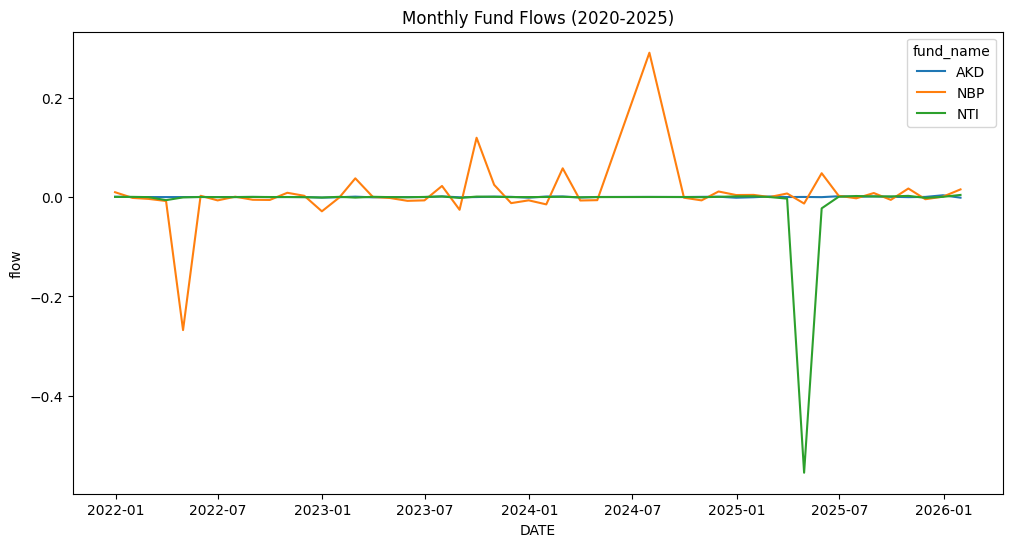

In [6]:
# Resample monthly (average flows across funds, sum volumes, etc.)
monthly_df = merged_df.set_index('DATE').groupby('fund_name').resample('ME').agg({
    'flow': 'mean',  # average flow per fund (or sum for total)
    'return': 'sum',  # cumulative monthly return
    'log_return': 'sum',  # from KSE-30
    'total_volume': 'sum',
    'PRICE': 'last',  # end-of-month
    'USD': 'last',
    'RATE': 'last'
}).reset_index()

# Create lagged features (key predictors for flows)
for lag in [1, 3]:
    monthly_df[f'return_lag{lag}'] = monthly_df.groupby('fund_name')['return'].shift(lag)
    monthly_df[f'PRICE_lag{lag}'] = monthly_df['PRICE'].shift(lag)
    monthly_df[f'USD_lag{lag}'] = monthly_df['USD'].shift(lag)
    monthly_df[f'RATE_lag{lag}'] = monthly_df['RATE'].shift(lag)

# Drop NaNs
monthly_df = monthly_df.dropna()

# Average flow across 3 funds for index-level prediction (or keep per-fund)
avg_monthly_df = monthly_df.groupby('DATE').agg({
    'flow': 'mean',
    'return': 'mean',
    'log_return': 'mean',
    'total_volume': 'sum',
    'PRICE': 'last',
    'USD': 'last',
    'RATE': 'last',
    'return_lag1': 'mean',
    'return_lag3': 'mean',
    'PRICE_lag1': 'last',
    'PRICE_lag3': 'last',
    'USD_lag1': 'last',
    'USD_lag3': 'last',
    'RATE_lag1': 'last',
    'RATE_lag3': 'last'
}).reset_index()

# Add 'date' column for compatibility with later cells
avg_monthly_df['date'] = avg_monthly_df['DATE']

# Plot flows
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_df, x='DATE', y='flow', hue='fund_name')
plt.title('Monthly Fund Flows (2020-2025)')
plt.show()

In [7]:
# Hurst Exponent (simple R/S on log returns)
def hurst_exponent(ts, min_lag=4, max_lag=None):
    ts = np.array(ts)
    N = len(ts)
    if max_lag is None:
        max_lag = N // 4
    lags, rs = [], []
    for lag in range(min_lag, max_lag + 1):
        rs_sub = []
        for k in range(0, N - lag, lag):
            sub = ts[k:k+lag]
            if len(sub) < 2: continue
            mean = np.mean(sub)
            y = sub - mean
            cum_dev = np.cumsum(y)
            r = np.max(cum_dev) - np.min(cum_dev)
            s = np.std(y)
            if s > 0:
                rs_sub.append(r / s)
        if rs_sub:
            lags.append(lag)
            rs.append(np.mean(rs_sub))
    if len(lags) < 3:
        return np.nan
    log_lags = np.log(lags)
    log_rs = np.log(rs)
    slope, _, _, _, _ = stats.linregress(log_lags, log_rs)
    return slope

Hurst Exponent (KSE-30/Funds): 0.918
Variance Ratio (q=3): 2.413


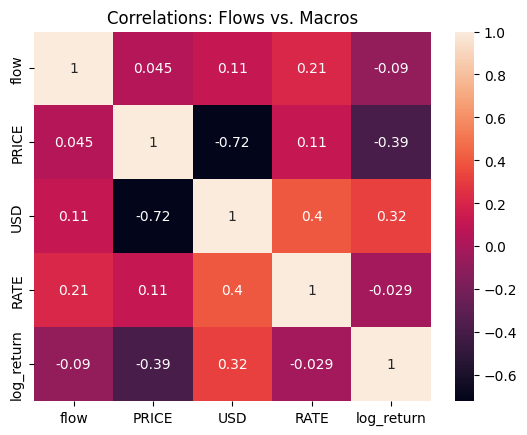

In [8]:
# Reuse Hurst from before
hurst = hurst_exponent(avg_monthly_df['log_return'].values)  # or use fund 'return'
print(f"Hurst Exponent (KSE-30/Funds): {hurst:.3f}")

# Variance Ratio (q=3)
q = 3
var1 = avg_monthly_df['log_return'].var()
var_q = avg_monthly_df['log_return'].rolling(q).sum().var()
vr = var_q / (q * var1)
print(f"Variance Ratio (q={q}): {vr:.3f}")

# Correlation with macros (for efficiency insights)
corr_matrix = avg_monthly_df[['flow', 'PRICE', 'USD', 'RATE', 'log_return']].corr()
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlations: Flows vs. Macros')
plt.show()

RF MSE: 0.0029750683506930605
RF R²: -0.0591142980852275
XGB MSE: 0.003443310122395561
XGB R²: -0.22580678945449284
Top Predictors:
 USD_lag3       0.499135
PRICE_lag3     0.250050
return_lag1    0.137218
return_lag3    0.067401
PRICE_lag1     0.032668
dtype: float32


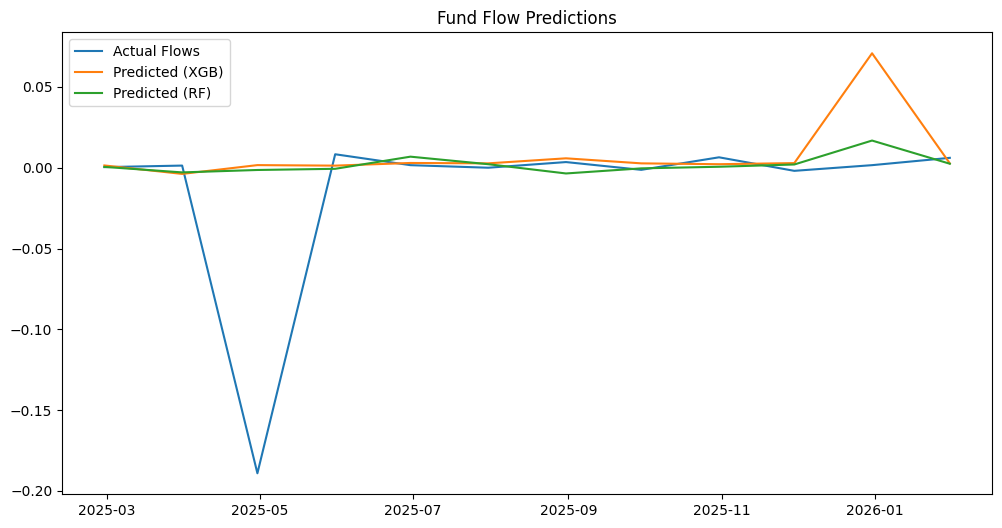

In [17]:
# Features (macros are strong: oil/forex/rates drive PK flows)
features = ['return_lag1', 'return_lag3',
            'PRICE_lag1', 'PRICE_lag3',
            'USD_lag1', 'USD_lag3',
            'RATE_lag1', 'RATE_lag3',
            'total_volume']  # add more

X = avg_monthly_df[features]
y = avg_monthly_df['flow'].shift(-1)  # next month's flow

X = X.iloc[:-1]
y = y.iloc[:-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
print("RF MSE:", mean_squared_error(y_test, preds_rf))
print("RF R²:", r2_score(y_test, preds_rf))

# XGBoost
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)  # tuned for small data
model_xgb.fit(X_train, y_train)
preds_xgb = model_xgb.predict(X_test)
print("XGB MSE:", mean_squared_error(y_test, preds_xgb))
print("XGB R²:", r2_score(y_test, preds_xgb))

# Importances
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=False)
print("Top Predictors:\n", importances.head())

# Plot
test_dates = avg_monthly_df['date'].iloc[-len(y_test):]
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, label='Actual Flows')
plt.plot(test_dates, preds_xgb, label='Predicted (XGB)')
plt.plot(test_dates, preds_rf, label='Predicted (RF)')
plt.title('Fund Flow Predictions')
plt.legend()
plt.show()

In [18]:
merged_df.head()

,DATE,NAV,AUM,return,flow,fund_name,index_return,log_return,total_volume,avg_weight_change,num_companies,PRICE,USD,RATE
3553,2020-03-18,10.0000,6.65,NaN,NaN,NTI,4.308332,0.302484,58324050.0,0.027055,30.0,NaN,NaN,NaN
3554,2020-03-24,9.6391,6.65,-0.036090,0.036090,NTI,4.804326,0.358860,21750797.0,0.029034,30.0,NaN,NaN,NaN
3555,2020-03-25,8.9289,6.65,-0.073679,0.073679,NTI,4.643605,0.366317,74584324.0,0.028824,30.0,NaN,NaN,NaN
3556,2020-03-26,8.4714,6.65,-0.051238,0.051238,NTI,4.537590,0.368547,75616330.0,0.029252,30.0,NaN,NaN,NaN
3557,2020-03-27,8.5156,6.65,0.005218,-0.005218,NTI,4.473735,0.359564,55411991.0,0.028793,30.0,NaN,NaN,NaN


In [19]:
# Predict next flow (using latest data)
latest_features = avg_monthly_df[features].iloc[-1:].values
next_flow_pred = model_xgb.predict(latest_features)[0]
print(f"Predicted Next Month Flow: {next_flow_pred:.4f}")

# Simple strategy: If positive flow, overweight funds with high recent returns
if next_flow_pred > 0:
    print("Positive flow predicted → Strategy: Overweight high-return funds/stocks")
    # Example tilt: Increase weights by 10% for top performers
    recent = merged_df[merged_df['DATE'] == merged_df['DATE'].max()].sort_values('return', ascending=False).head()
    print("Suggested Overweight:\n", recent[['fund_name', 'return', 'index_return']])  # if weights available
else:
    print("Neutral/Negative → Strategy: Equal-weight or defensive (e.g., add bond exposure via rates)")

# For advanced: Use PyPortfolioOpt (pip install PyPortfolioOpt)
# from pypfopt import expected_returns, risk_models, EfficientFrontier
# ... compute optimal weights based on predicted returns = f(flow_pred)

Predicted Next Month Flow: 0.0023
Positive flow predicted → Strategy: Overweight high-return funds/stocks
Suggested Overweight:
      fund_name    return  index_return
3552       NBP  0.012679      2.084501
5673       NTI  0.010940      2.084501
1636       AKD -0.000025      2.084501
